#Segmentation Inference & Bounding Box Visualization



## 0. Imports & Config

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import random
import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.metrics import roc_curve, auc, precision_recall_curve

from src.inference.segment import (
    load_model, run_segmentation,
    save_overlay, save_binary_mask, save_report,
    BoundingBox, SegmentationResult,
    MIN_AREA, MAX_AREA, MAX_ASPECT, CLUSTER_DIST,
)

CKPT      = Path('../checkpoints/unet_best.pth')
TEST_IMG  = Path('../data/patches/segmentation/test/images')
TEST_MASK = Path('../data/patches/segmentation/test/masks')
PROC_DIR  = Path('../data/processed/inbreast/AllPng')   # full mammograms
OUT_DIR   = Path('../outputs/segment_inference')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE    = 'cpu'
THRESHOLD = 0.45  

print(f'Device    : {DEVICE}')
print(f'Checkpoint: {CKPT} — exists={CKPT.exists()}')
print(f'Test imgs : {len(list(TEST_IMG.glob("*.png")))} patches')
print(f'Full mams : {len(list(PROC_DIR.glob("*.png")))} images')

Device    : cpu
Checkpoint: ..\checkpoints\unet_best.pth — exists=True
Test imgs : 184 patches
Full mams : 313 images


## 1. Load Model

In [2]:
model, device = load_model(CKPT, device=DEVICE)
print(f'Model loaded on {device}')
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

[segment] Loaded checkpoint — epoch=215  fold=3  optimizer_state_dict={'state': {0: {'momentum_buffer': tensor([[[[-5.3076e-03, -8.8935e-03, -4.3740e-03],
          [-3.0448e-02, -1.1833e-02, -2.0752e-02],
          [-5.8120e-03, -5.6567e-03, -3.9253e-03]]],


        [[[ 2.6779e-02,  2.5284e-02,  2.0677e-02],
          [ 1.0975e-02,  6.2573e-04,  7.9419e-03],
          [ 1.8933e-02,  1.4180e-02,  1.9311e-02]]],


        [[[ 1.1327e-02,  9.7871e-03,  6.8438e-03],
          [ 1.0814e-02,  6.3533e-03,  3.3631e-03],
          [ 1.3298e-02,  9.3677e-03,  9.0544e-03]]],


        [[[-2.3956e-02, -2.3462e-02, -1.8651e-02],
          [-3.1878e-02, -3.2608e-02, -2.0840e-02],
          [-4.4230e-04, -6.8009e-03, -7.2698e-03]]],


        [[[ 6.7208e-03,  2.9014e-03,  1.4960e-03],
          [ 2.8465e-03, -2.5441e-04,  6.0417e-04],
          [ 6.3220e-03,  1.1002e-03,  2.0826e-03]]],


        [[[-4.3735e-03, -5.6593e-03, -2.5918e-03],
          [-3.5240e-03, -4.7414e-03, -1.7800e-03],
         

## 2. Single Image Inference

In [3]:
test_images = sorted(TEST_IMG.glob('*.png'))
rand_idx = random.randint(0, min(310, len(test_images)-1))
img_path    = test_images[rand_idx]  
mask_path   = TEST_MASK / img_path.name

print(f'Image : {img_path.name}')

result = run_segmentation(
    image_path   = img_path,
    model        = model,
    device       = device,
    threshold    = THRESHOLD,
    tta          = False,
    min_area     = MIN_AREA,
    max_area     = MAX_AREA,
    max_aspect   = MAX_ASPECT,
    cluster_dist = CLUSTER_DIST,
)

print(f'Inference     : {result.inference_ms:.1f} ms  (TTA={result.tta_used})')
print(f'Raw MC detections : {len(result.raw_bboxes)}')
print(f'Clusters found    : {len(result.bboxes)}')
for bb in result.bboxes:
    print(f'  C{bb.region_id:02d}  bbox=[{bb.x1},{bb.y1},{bb.x2},{bb.y2}]  '
          f'{bb.width}x{bb.height}px  total_area={bb.area}px')


Image : 22580038_6200187f3f1ccc18_MG_L_CC_ANON_768_768.png
Inference     : 874.0 ms  (TTA=False)
Raw MC detections : 1
Clusters found    : 1
  C01  bbox=[0,67,49,141]  49x74px  total_area=100px


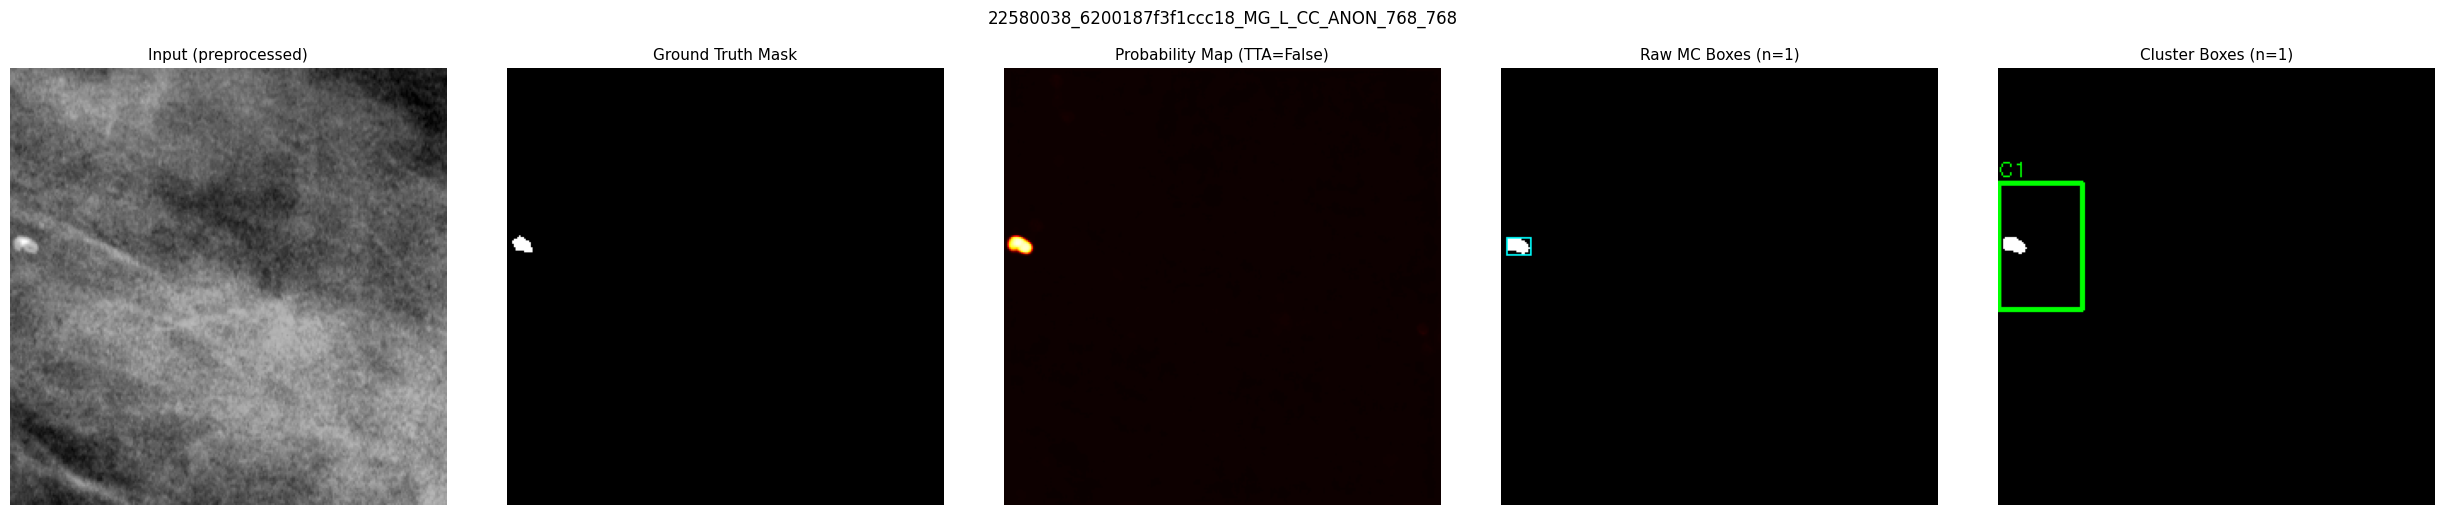

In [4]:
img_gray  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
gt_mask   = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path.exists() else None
pred_bin  = result.binary_mask
prob_map  = result.prob_map

has_gt = gt_mask is not None
n_cols = 5 if has_gt else 4
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

col = 0
axes[col].imshow(img_gray, cmap='gray')
axes[col].set_title('Input (preprocessed)', fontsize=11)
axes[col].axis('off'); col += 1

if has_gt:
    axes[col].imshow(gt_mask, cmap='gray')
    axes[col].set_title('Ground Truth Mask', fontsize=11)
    axes[col].axis('off'); col += 1

axes[col].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
axes[col].set_title(f'Probability Map (TTA={result.tta_used})', fontsize=11)
axes[col].axis('off'); col += 1

# Raw individual MC boxes (cyan) — pre-clustering
raw_rgb = cv2.cvtColor(pred_bin, cv2.COLOR_GRAY2RGB)
for bb in result.raw_bboxes:
    cv2.rectangle(raw_rgb, (bb.x1, bb.y1), (bb.x2, bb.y2), (0, 255, 255), 1)  # cyan
axes[col].imshow(raw_rgb)
axes[col].set_title(f'Raw MC Boxes (n={len(result.raw_bboxes)})', fontsize=11)
axes[col].axis('off'); col += 1

# Cluster boxes (green) — classifier input
cls_rgb = cv2.cvtColor(pred_bin, cv2.COLOR_GRAY2RGB)
for bb in result.bboxes:
    cv2.rectangle(cls_rgb, (bb.x1, bb.y1), (bb.x2, bb.y2), (0, 255, 0), 2)  # green
    cv2.putText(cls_rgb, f'C{bb.region_id}', (bb.x1, max(bb.y1-4, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
axes[col].imshow(cls_rgb)
axes[col].set_title(f'Cluster Boxes (n={len(result.bboxes)})', fontsize=11)
axes[col].axis('off')

plt.suptitle(img_path.stem, fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'single_inference.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Threshold Sweep

In [5]:
all_probs  = []
all_labels = []

for img_p in tqdm(test_images, desc='Collecting probs'):
    msk_p = TEST_MASK / img_p.name
    if not msk_p.exists():
        continue

    res = run_segmentation(
        image_path = img_p,
        model      = model,
        device     = device,
        threshold  = 0.5,   # threshold doesn't matter here — we use prob_map
        tta        = False,  # disabled — +0.004 IoU not worth 4x cost on full mam
        min_area   = 0,     # no CC filter for pixel-level sweep
    )

    gt = (cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    all_probs.append(res.prob_map.flatten())
    all_labels.append(gt.flatten())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
print(f'Total pixels : {len(all_probs):,}')
print(f'Positive px  : {all_labels.sum():,}  ({100*all_labels.mean():.2f}%)')

Total pixels : 12,058,624
Positive px  : 29,576  (0.25%)


In [6]:
thresholds = np.arange(0.1, 0.95, 0.05)
rows = []

for t in thresholds:
    pred = (all_probs >= t).astype(np.uint8)
    tp = np.logical_and(pred, all_labels).sum()
    fp = np.logical_and(pred, 1 - all_labels).sum()
    fn = np.logical_and(1 - pred, all_labels).sum()

    iou  = tp / (tp + fp + fn + 1e-8)
    dice = 2*tp / (2*tp + fp + fn + 1e-8)
    sens = tp / (tp + fn + 1e-8)
    spec = 1 - fp / (fp + (all_labels == 0).sum() + 1e-8)
    rows.append({'threshold': round(t, 2), 'IoU': iou, 'Dice': dice,
                 'Sensitivity': sens, 'Specificity': spec})

sweep_df = pd.DataFrame(rows)
best_iou_row  = sweep_df.loc[sweep_df['IoU'].idxmax()]
best_dice_row = sweep_df.loc[sweep_df['Dice'].idxmax()]

print(f"Best IoU  @ threshold={best_iou_row['threshold']:.2f}  →  IoU={best_iou_row['IoU']:.4f}  Dice={best_iou_row['Dice']:.4f}")
print(f"Best Dice @ threshold={best_dice_row['threshold']:.2f}  →  IoU={best_dice_row['IoU']:.4f}  Dice={best_dice_row['Dice']:.4f}")
sweep_df.round(4)

Best IoU  @ threshold=0.50  →  IoU=0.6327  Dice=0.7751
Best Dice @ threshold=0.50  →  IoU=0.6327  Dice=0.7751


,threshold,IoU,Dice,Sensitivity,Specificity
0,0.10,0.5599,0.7179,0.8572,0.9987
1,0.15,0.5862,0.7391,0.8426,0.9989
2,0.20,0.6020,0.7515,0.8313,0.9991
3,0.25,0.6120,0.7593,0.8195,0.9992
4,0.30,0.6194,0.7650,0.8085,0.9993
5,0.35,0.6238,0.7683,0.7976,0.9993
6,0.40,0.6284,0.7718,0.7878,0.9994
7,0.45,0.6308,0.7736,0.7767,0.9994
8,0.50,0.6327,0.7751,0.7658,0.9995
9,0.55,0.6317,0.7743,0.7525,0.9995


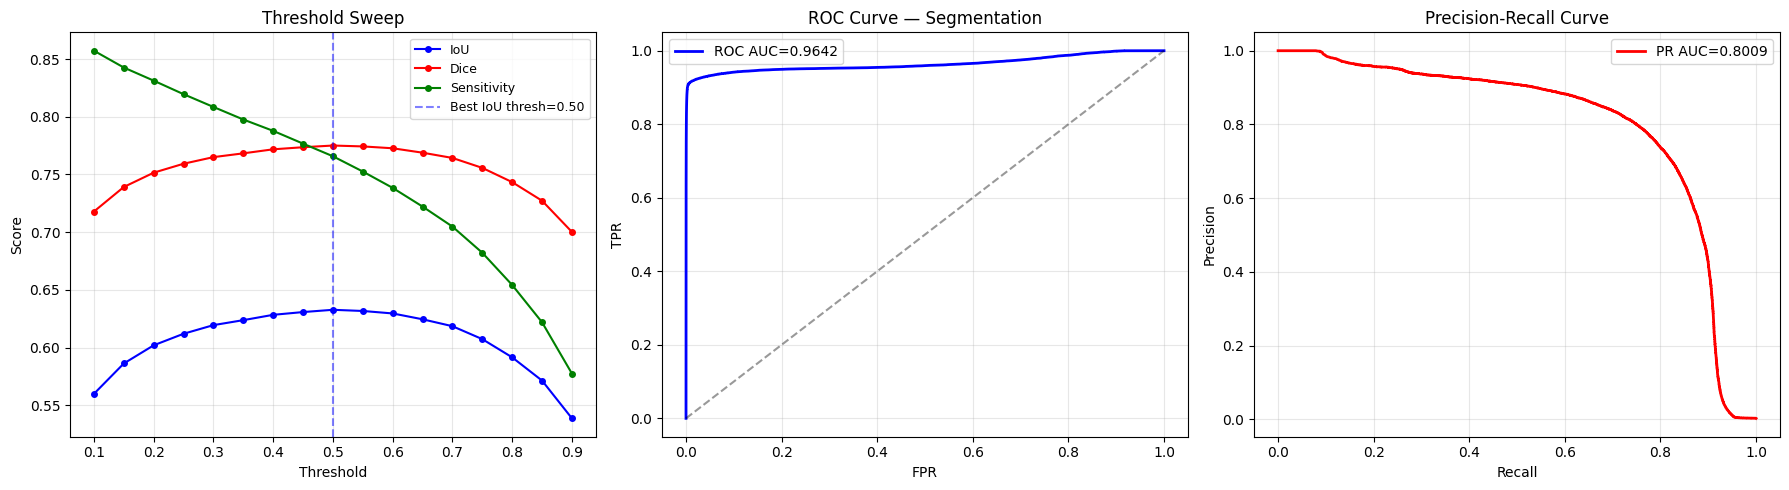

AUC-ROC: 0.9642
AUC-PR : 0.8009


In [7]:
fpr, tpr, roc_thresh = roc_curve(all_labels, all_probs)
prec, rec, _         = precision_recall_curve(all_labels, all_probs)
auc_roc = auc(fpr, tpr)
auc_pr  = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Threshold sweep
ax = axes[0]
ax.plot(sweep_df['threshold'], sweep_df['IoU'],         'b-o', ms=4, label='IoU')
ax.plot(sweep_df['threshold'], sweep_df['Dice'],        'r-o', ms=4, label='Dice')
ax.plot(sweep_df['threshold'], sweep_df['Sensitivity'], 'g-o', ms=4, label='Sensitivity')
ax.axvline(best_iou_row['threshold'], color='blue', ls='--', alpha=0.5,
           label=f"Best IoU thresh={best_iou_row['threshold']:.2f}")
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Sweep'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ROC
ax = axes[1]
ax.plot(fpr, tpr, 'b-', lw=2, label=f'ROC AUC={auc_roc:.4f}')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve — Segmentation'); ax.legend(); ax.grid(alpha=0.3)

# PR
ax = axes[2]
ax.plot(rec, prec, 'r-', lw=2, label=f'PR AUC={auc_pr:.4f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'threshold_sweep_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {auc_roc:.4f}')
print(f'AUC-PR : {auc_pr:.4f}')

In [8]:
# ── Update working threshold based on sweep ────────────────────────────────
BEST_THRESHOLD = float(best_iou_row['threshold'])
print(f'Using threshold = {BEST_THRESHOLD} for all subsequent cells')

Using threshold = 0.5 for all subsequent cells


## 4. Batch Inference on Test Set


In [9]:
records = []

for img_p in tqdm(test_images, desc='Batch inference'):
    msk_p = TEST_MASK / img_p.name
    if not msk_p.exists():
        continue

    res = run_segmentation(
        image_path   = img_p,
        model        = model,
        device       = device,
        threshold    = BEST_THRESHOLD,
        tta          = False,
        min_area     = MIN_AREA,
        max_area     = MAX_AREA,
        max_aspect   = MAX_ASPECT,
        cluster_dist = CLUSTER_DIST,
    )

    gt    = (cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    pred  = (res.binary_mask > 127).astype(np.uint8)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, 1 - gt).sum()
    fn = np.logical_and(1 - pred, gt).sum()

    iou  = tp / (tp + fp + fn + 1e-8)
    dice = 2*tp / (2*tp + fp + fn + 1e-8)
    sens = tp / (tp + fn + 1e-8)

    records.append({
        'filename'    : img_p.name,
        'IoU'         : iou,
        'Dice'        : dice,
        'Sensitivity' : sens,
        'n_raw_mc'    : len(res.raw_bboxes), 
        'n_clusters'  : len(res.bboxes),        
        'max_prob'    : float(res.prob_map.max()),
        'mean_prob'   : float(res.prob_map.mean()),
        'inf_ms'      : res.inference_ms,
        '_result'     : res,
        '_img_path'   : img_p,
    })

df = pd.DataFrame(records)
print('-' * 55)
print(f'  Test patches      : {len(df)}')
print(f'  IoU    mean±std   : {df["IoU"].mean():.4f} ± {df["IoU"].std():.4f}')
print(f'  Dice   mean±std   : {df["Dice"].mean():.4f} ± {df["Dice"].std():.4f}')
print(f'  Sens   mean±std   : {df["Sensitivity"].mean():.4f} ± {df["Sensitivity"].std():.4f}')
print(f'  Avg raw MC/patch  : {df["n_raw_mc"].mean():.1f}')
print(f'  Avg clusters/patch: {df["n_clusters"].mean():.1f}')
print(f'  Avg inference     : {df["inf_ms"].mean():.1f} ms/patch')
print('-' * 55)


Batch inference:   0%|          | 0/184 [00:00<?, ?it/s]

-------------------------------------------------------
  Test patches      : 184
  IoU    mean±std   : 0.5521 ± 0.3045
  Dice   mean±std   : 0.6507 ± 0.3161
  Sens   mean±std   : 0.6848 ± 0.3310
  Avg raw MC/patch  : 0.5
  Avg clusters/patch: 0.4
  Avg inference     : 554.8 ms/patch
-------------------------------------------------------


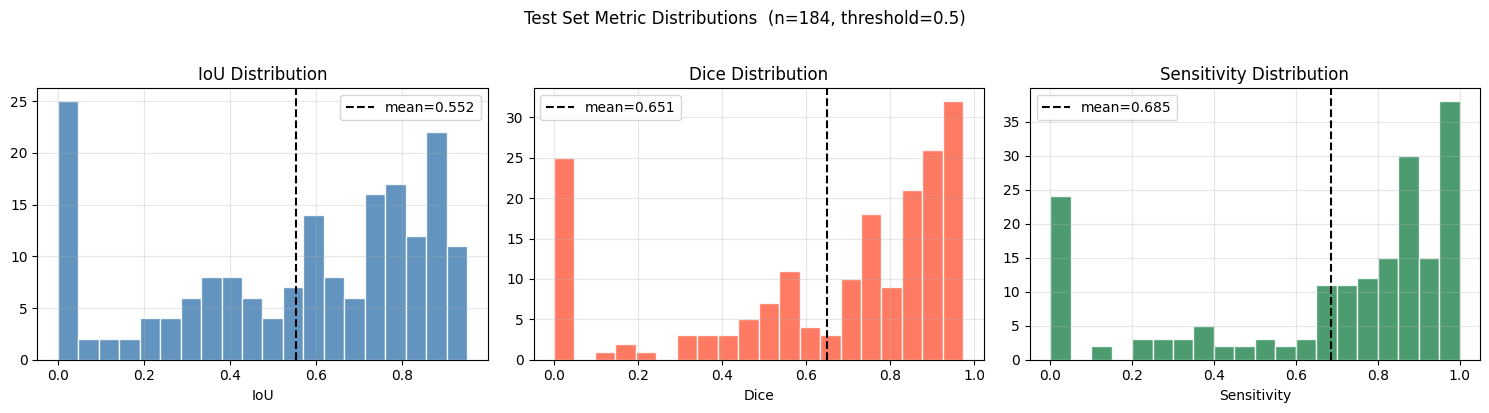

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, title in zip(
    axes,
    ['IoU', 'Dice', 'Sensitivity'],
    ['steelblue', 'tomato', 'seagreen'],
    ['IoU Distribution', 'Dice Distribution', 'Sensitivity Distribution']
):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', ls='--', lw=1.5,
               label=f'mean={df[col].mean():.3f}')
    ax.set_title(title); ax.set_xlabel(col); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'Test Set Metric Distributions  (n={len(df)}, threshold={BEST_THRESHOLD})', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:

from src.inference.segment import centroid_detection_metrics

det_records = []
for row in tqdm(records, desc='Centroid metrics'):
    msk_p  = TEST_MASK / row['_img_path'].name
    if not msk_p.exists(): continue
    gt_mask = cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE)
    metrics = centroid_detection_metrics(
        pred_bboxes = row['_result'].raw_bboxes,  # individual MCs, not clusters
        gt_mask     = gt_mask,
        radius_px   = 10.0,
    )
    det_records.append(metrics)

det_df = pd.DataFrame(det_records)
total_tp = det_df['TP'].sum()
total_fp = det_df['FP'].sum()
total_fn = det_df['FN'].sum()
det_precision = total_tp / (total_tp + total_fp + 1e-8)
det_recall    = total_tp / (total_tp + total_fn + 1e-8)
det_f1        = 2 * det_precision * det_recall / (det_precision + det_recall + 1e-8)

print('Detection Metrics (centroid distance <= 10px, individual MC level)')
print('-' * 55)
print(f'  Total GT dots  : {total_tp + total_fn}')
print(f'  TP             : {total_tp}  (correct detections)')
print(f'  FP             : {total_fp}  (false alarms)')
print(f'  FN             : {total_fn}  (missed MCs)')
print(f'  Precision      : {det_precision:.4f}')
print(f'  Recall         : {det_recall:.4f}  <- true clinical sensitivity')
print(f'  F1             : {det_f1:.4f}')
print('-' * 55)
print()
print('Summary — pixel IoU vs detection recall:')
print(f'  IoU mean       : {df["IoU"].mean():.4f}  (limited by 1px GT annotation size)')
print(f'  Det Recall     : {det_recall:.4f}  (honest clinical sensitivity)')
print(f'  Det Precision  : {det_precision:.4f}')


Centroid metrics:   0%|          | 0/184 [00:00<?, ?it/s]

Detection Metrics (centroid distance <= 10px, individual MC level)
-------------------------------------------------------
  Total GT dots  : 383
  TP             : 80  (correct detections)
  FP             : 7  (false alarms)
  FN             : 303  (missed MCs)
  Precision      : 0.9195
  Recall         : 0.2089  <- true clinical sensitivity
  F1             : 0.3404
-------------------------------------------------------

Summary — pixel IoU vs detection recall:
  IoU mean       : 0.5521  (limited by 1px GT annotation size)
  Det Recall     : 0.2089  (honest clinical sensitivity)
  Det Precision  : 0.9195


## 4b. Verify Wire/Artifact Filter


In [12]:
sample_paths_wire = test_images[:50]
filtered_counts, unfiltered_counts = [], []

for img_p in tqdm(sample_paths_wire, desc='Wire filter check'):
    r_filtered = run_segmentation(img_p, model, device,
                                  threshold=BEST_THRESHOLD, tta=False,
                                  min_area=MIN_AREA, max_area=MAX_AREA,
                                  max_aspect=MAX_ASPECT, cluster_dist=0)
    r_unfiltered = run_segmentation(img_p, model, device,
                                    threshold=BEST_THRESHOLD, tta=False,
                                    min_area=MIN_AREA, max_area=9999999,
                                    max_aspect=999.0, cluster_dist=0)
    filtered_counts.append(len(r_filtered.raw_bboxes))
    unfiltered_counts.append(len(r_unfiltered.raw_bboxes))

removed = sum(u - f for u, f in zip(unfiltered_counts, filtered_counts))
print(f'Raw MCs kept    : {sum(filtered_counts)}')
print(f'Artifacts removed: {removed}  (wires/blobs)')
print(f'Removal rate    : {100*removed/(sum(unfiltered_counts)+1e-8):.1f}%')


Wire filter check:   0%|          | 0/50 [00:00<?, ?it/s]

Raw MCs kept    : 35
Artifacts removed: 2  (wires/blobs)
Removal rate    : 5.4%


## 5. Best / Worst Predictions


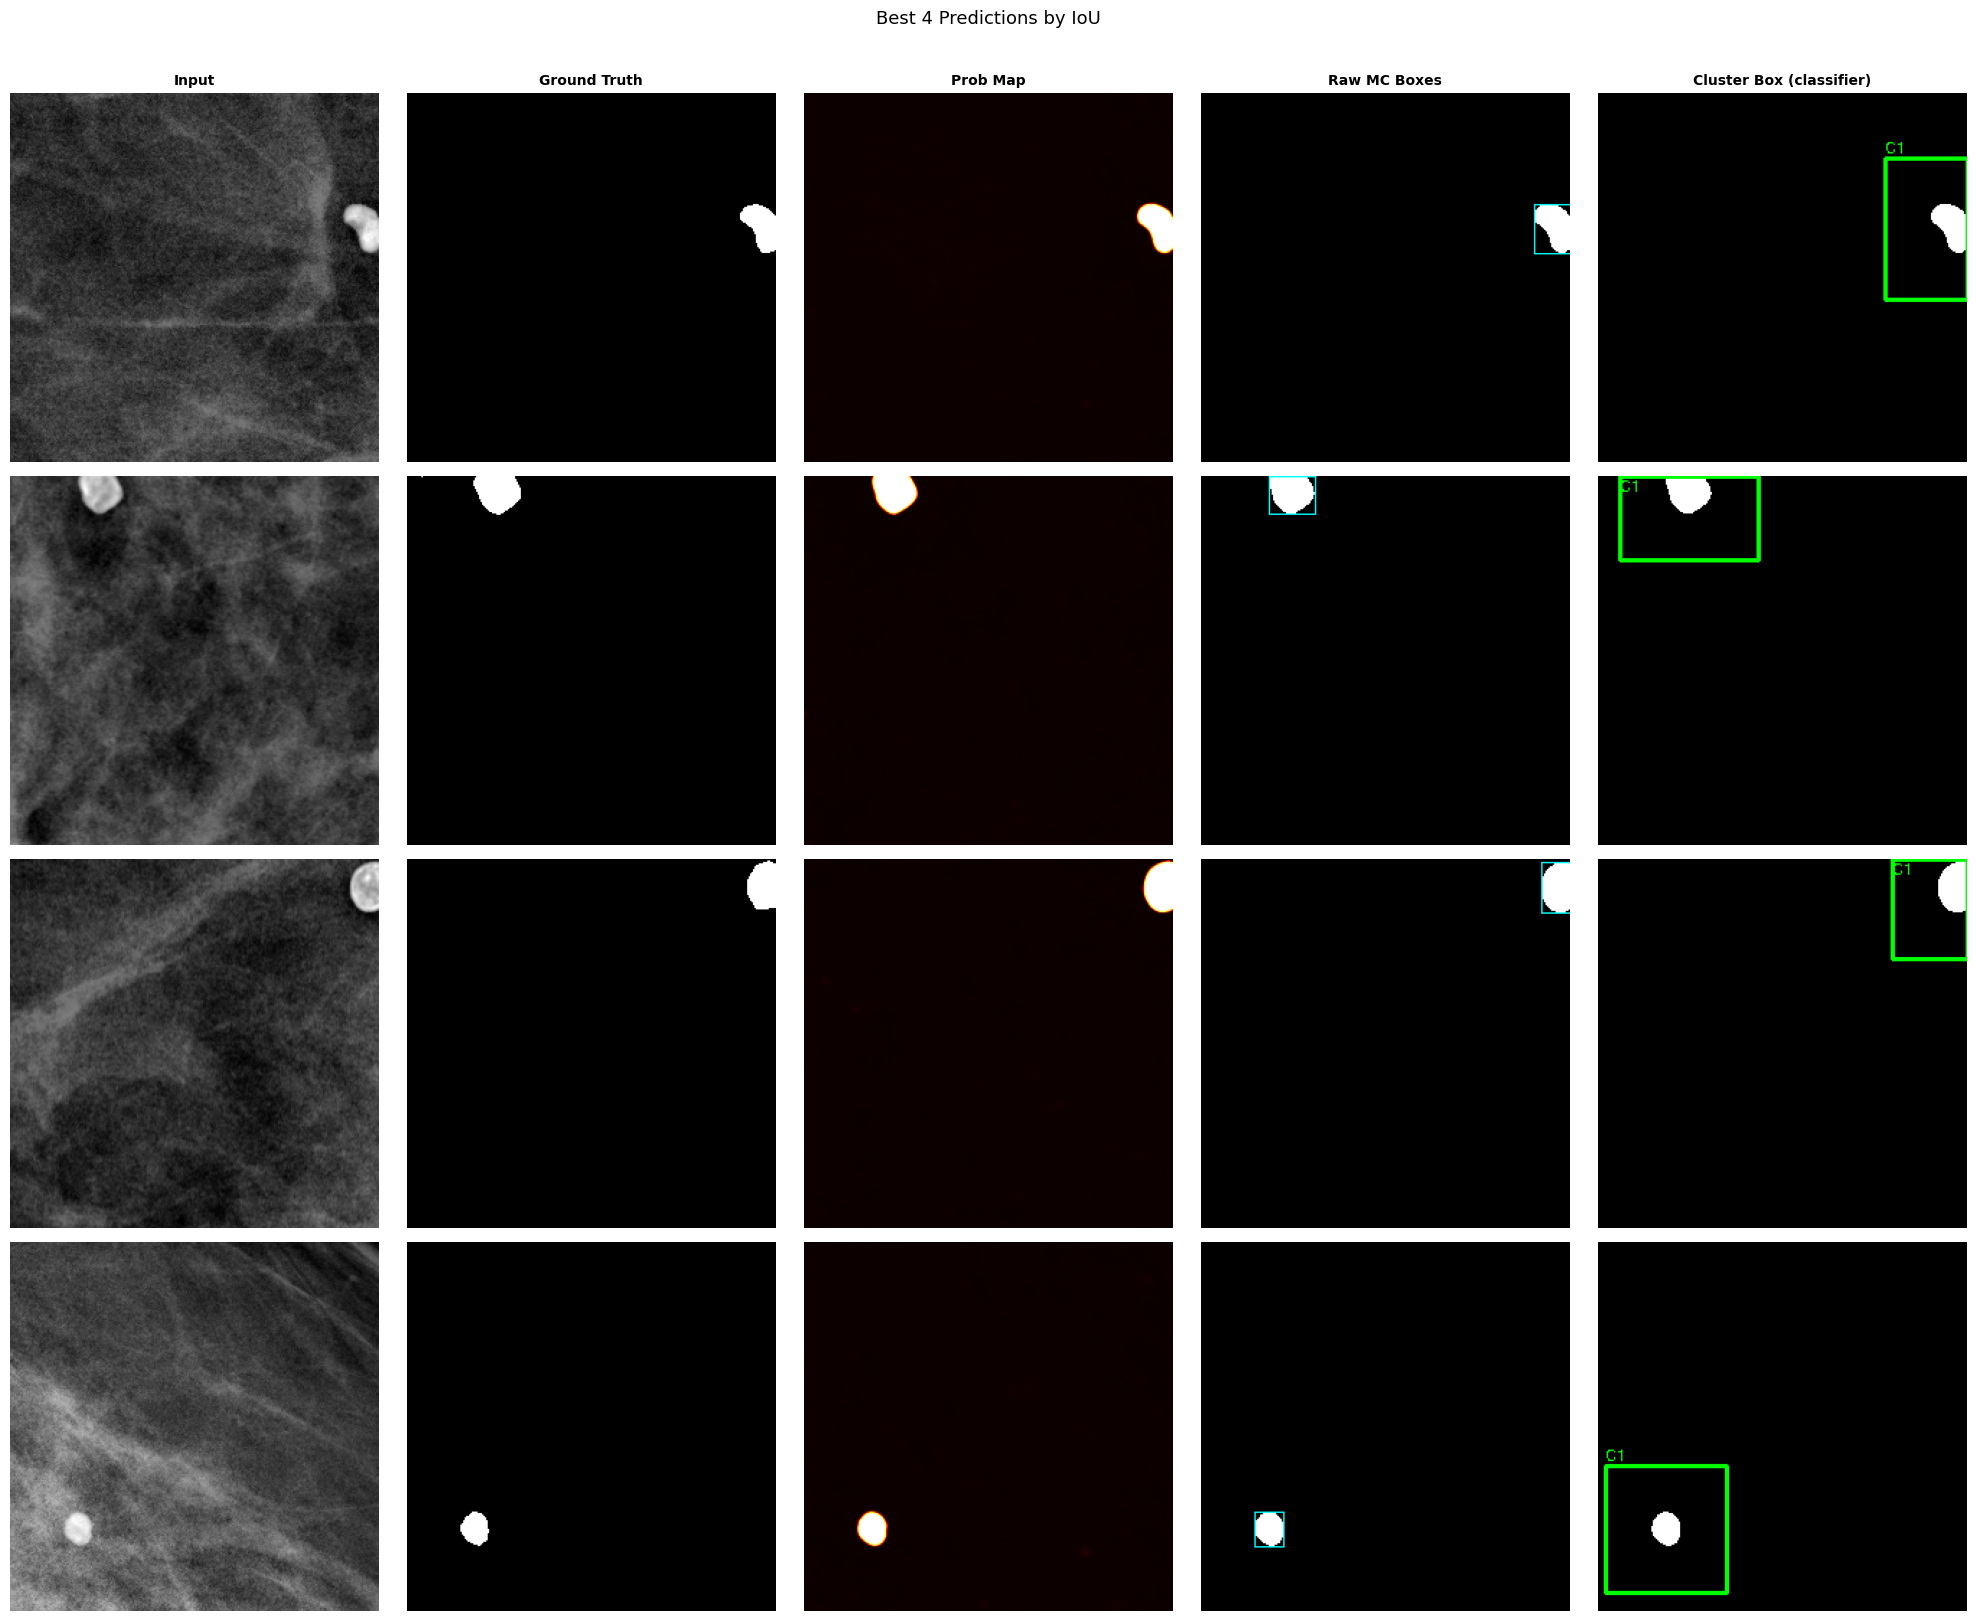

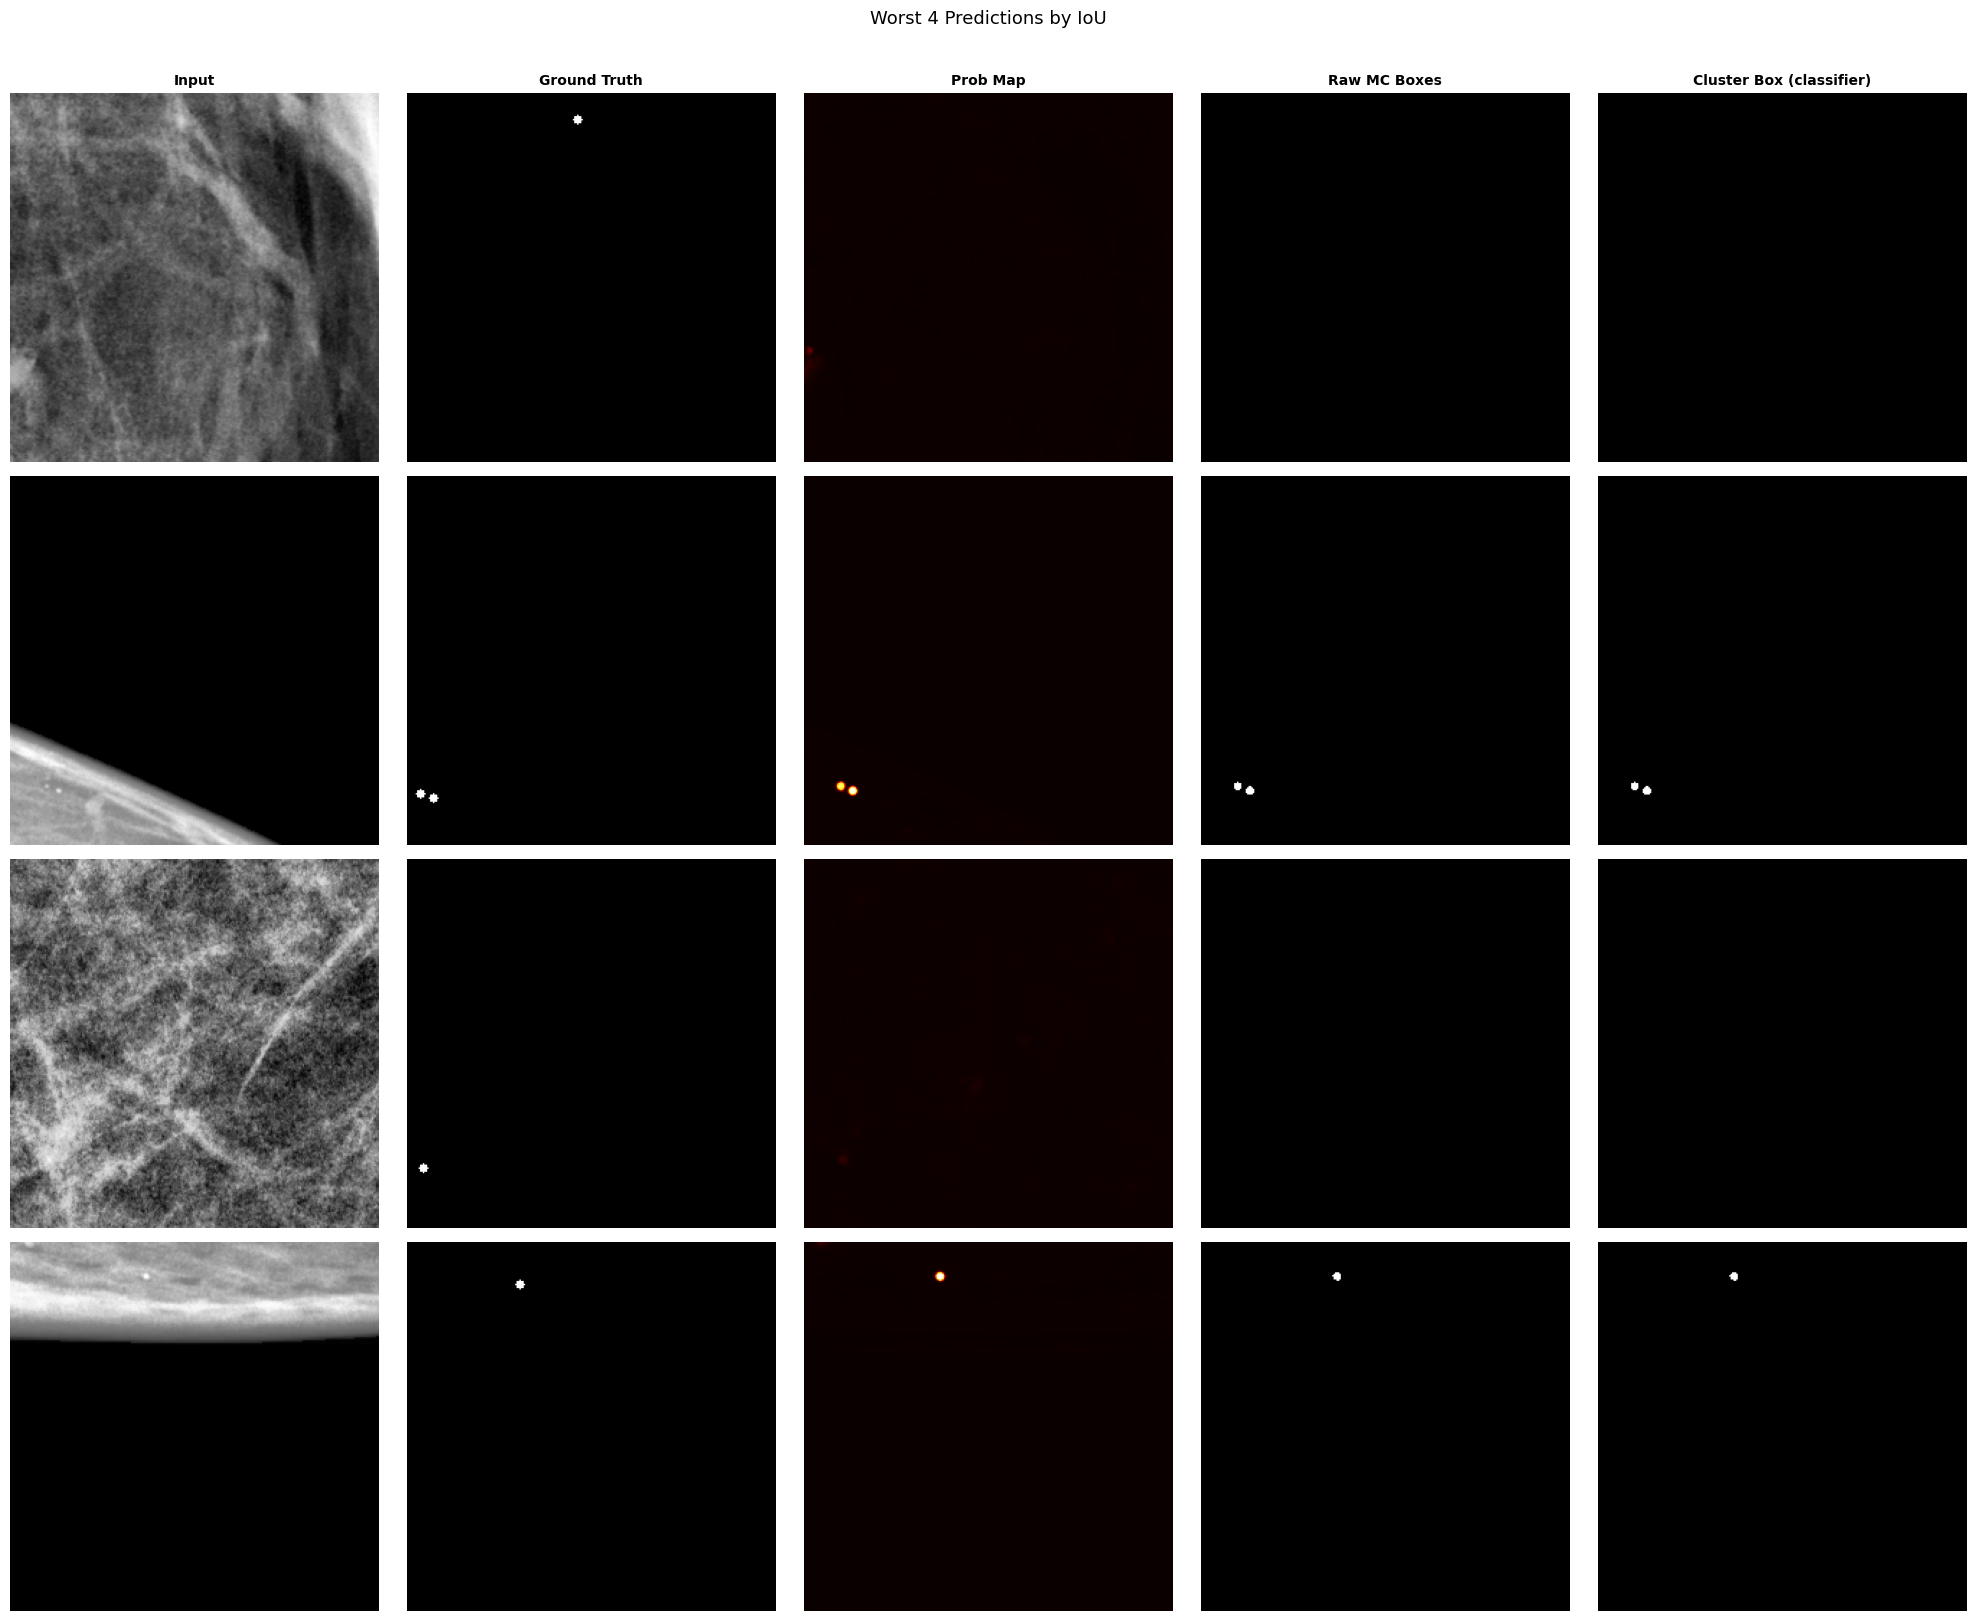

In [13]:
def plot_prediction_grid(rows_data, title, save_name):
    """5 cols: original | GT | prob map | raw MC boxes (cyan) | cluster boxes (green)"""
    n = len(rows_data)
    fig, axes = plt.subplots(n, 5, figsize=(20, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Input', 'Ground Truth', 'Prob Map',
                  'Raw MC Boxes', 'Cluster Box (classifier)']
    for j, ct in enumerate(col_titles):
        axes[0, j].set_title(ct, fontsize=10, fontweight='bold')

    for i, row in enumerate(rows_data):
        res   = row['_result']
        img_p = row['_img_path']
        msk_p = TEST_MASK / img_p.name

        img_gray = cv2.imread(str(img_p), cv2.IMREAD_GRAYSCALE)
        gt_mask  = cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE) if msk_p.exists() else np.zeros_like(img_gray)

        # Cyan = individual raw MC boxes
        raw_rgb = cv2.cvtColor(res.binary_mask, cv2.COLOR_GRAY2RGB)
        for bb in res.raw_bboxes:
            cv2.rectangle(raw_rgb, (bb.x1, bb.y1), (bb.x2, bb.y2), (0, 255, 255), 1)

        # Green = merged cluster boxes (classifier input)
        cls_rgb = cv2.cvtColor(res.binary_mask, cv2.COLOR_GRAY2RGB)
        for bb in res.bboxes:
            cv2.rectangle(cls_rgb, (bb.x1, bb.y1), (bb.x2, bb.y2), (0, 255, 0), 2)
            cv2.putText(cls_rgb, f'C{bb.region_id}', (bb.x1, max(bb.y1-4, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 0), 1)

        axes[i, 0].imshow(img_gray,       cmap='gray')
        axes[i, 1].imshow(gt_mask,        cmap='gray')
        axes[i, 2].imshow(res.prob_map,   cmap='hot', vmin=0, vmax=1)
        axes[i, 3].imshow(raw_rgb)
        axes[i, 4].imshow(cls_rgb)

        iou_str = (f"IoU={row['IoU']:.3f}  Dice={row['Dice']:.3f}  "
                   f"raw={row['n_raw_mc']}  clusters={row['n_clusters']}")
        axes[i, 0].set_ylabel(f"{img_p.stem[:20]}\n{iou_str}", fontsize=7)
        for ax in axes[i]: ax.axis('off')

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()


top4 = df.nlargest(4,  'IoU').to_dict('records')
bot4 = df.nsmallest(4, 'IoU').to_dict('records')

plot_prediction_grid(top4, 'Best 4 Predictions by IoU',  'best_predictions.png')
plot_prediction_grid(bot4, 'Worst 4 Predictions by IoU', 'worst_predictions.png')


## 6. Full Mammogram Inference


In [14]:

full_mam_paths = sorted(PROC_DIR.glob('*.png'))

if not full_mam_paths:
    print('No processed mammograms found in', PROC_DIR)
else:
    "rand_idx = random.randint(0, min(310, len(full_mam_paths)-1))"
    rand_idx=4
    full_path = full_mam_paths[rand_idx]
    print(f'Running on: {full_path.name} (index={rand_idx})')

    full_result = run_segmentation(
        image_path = full_path,
        model      = model,
        device     = device,
        threshold  = BEST_THRESHOLD,
        tta        = False,
        min_area   = MIN_AREA,
        max_area   = MAX_AREA,
        max_aspect = MAX_ASPECT,
    )

    print(f'Image size    : {cv2.imread(str(full_path), cv2.IMREAD_GRAYSCALE).shape}')
    print(f'Mask size     : {full_result.binary_mask.shape}')
    print(f'Regions found : {len(full_result.bboxes)}')
    print(f'Inference     : {full_result.inference_ms:.0f} ms')

    for bb in full_result.bboxes:
        print(f'  R{bb.region_id:02d}  [{bb.x1},{bb.y1} → {bb.x2},{bb.y2}]  '
              f'size={bb.width}×{bb.height}px  area={bb.area}px')

Running on: 20587148_fd746d25eb40b3dc_MG_R_CC_ANON.png (index=4)
Image size    : (2511, 930)
Mask size     : (2511, 930)
Regions found : 2
Inference     : 22108 ms
  R01  [559,1020 → 643,1104]  size=84×84px  area=316px
  R02  [364,915 → 438,989]  size=74×74px  area=68px


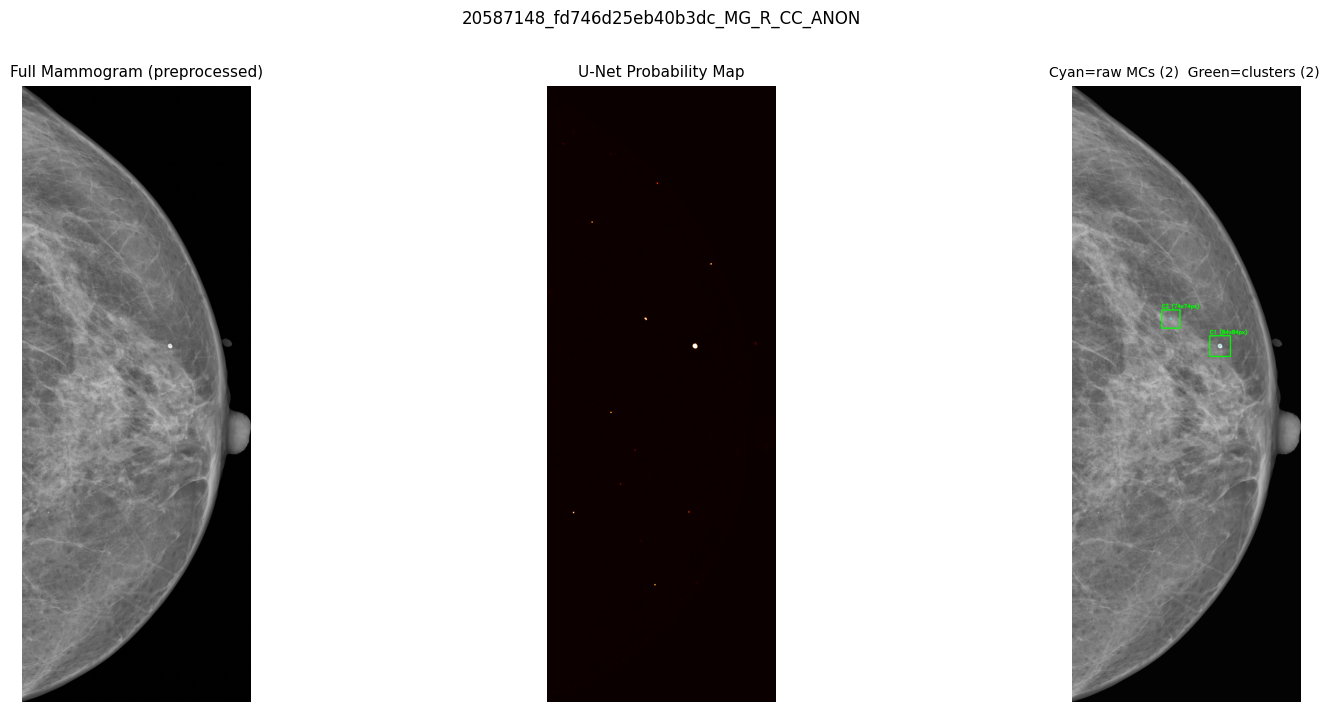

In [16]:
if full_mam_paths:
    img_full = cv2.imread(str(full_path), cv2.IMREAD_GRAYSCALE)
    canvas   = cv2.cvtColor(img_full, cv2.COLOR_GRAY2RGB)


    for bb in full_result.raw_bboxes:
        cx, cy = int(bb.centroid[0]), int(bb.centroid[1])
        cv2.circle(canvas, (cx, cy), 3, (0, 255, 255), -1)  

    
    for bb in full_result.bboxes:
        cv2.rectangle(canvas, (bb.x1, bb.y1), (bb.x2, bb.y2), (0, 255, 0), 3)
        label = f'C{bb.region_id} ({bb.width}x{bb.height}px)'
        cv2.putText(canvas, label, (bb.x1, max(bb.y1-8, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    axes[0].imshow(img_full, cmap='gray')
    axes[0].set_title('Full Mammogram (preprocessed)', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(full_result.prob_map, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('U-Net Probability Map', fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(canvas)
    axes[2].set_title(
        f'Cyan=raw MCs ({len(full_result.raw_bboxes)})  '
        f'Green=clusters ({len(full_result.bboxes)}) ', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(full_path.stem, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'full_mam_{full_path.stem}.png', dpi=150, bbox_inches='tight')
    plt.show()


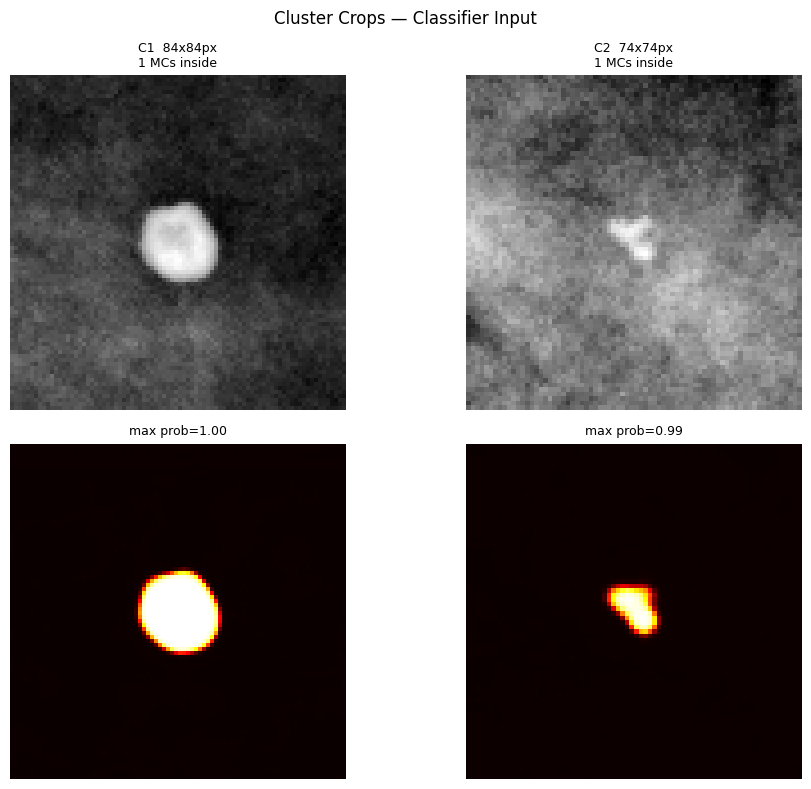

In [17]:
if full_mam_paths and full_result.bboxes:
    clusters = full_result.bboxes
    ncols    = min(len(clusters), 4)
    fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 8))
    if ncols == 1: axes = axes[:, np.newaxis]

    for j, bb in enumerate(clusters[:ncols]):
        crop_img  = img_full[bb.y1:bb.y2, bb.x1:bb.x2]
        crop_prob = full_result.prob_map[bb.y1:bb.y2, bb.x1:bb.x2]

        mc_in_cluster = sum(
            1 for r in full_result.raw_bboxes
            if bb.x1 <= r.centroid[0] <= bb.x2 and bb.y1 <= r.centroid[1] <= bb.y2
        )

        axes[0, j].imshow(crop_img, cmap='gray')
        axes[0, j].set_title(
            f'C{bb.region_id}  {bb.width}x{bb.height}px\n{mc_in_cluster} MCs inside',
            fontsize=9)
        axes[0, j].axis('off')

        axes[1, j].imshow(crop_prob, cmap='hot', vmin=0, vmax=1)
        axes[1, j].set_title(f'max prob={crop_prob.max():.2f}', fontsize=9)
        axes[1, j].axis('off')

    axes[0, 0].set_ylabel('Classifier Input Crop', fontsize=10)
    axes[1, 0].set_ylabel('Prob Map Crop', fontsize=10)
    plt.suptitle('Cluster Crops — Classifier Input', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'cluster_crops.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. TTA vs No-TTA Comparison

TTA comparison:   0%|          | 0/30 [00:00<?, ?it/s]

No TTA  IoU: 0.5189 ± 0.3689
TTA     IoU: 0.5205 ± 0.3637
Delta       : +0.0016


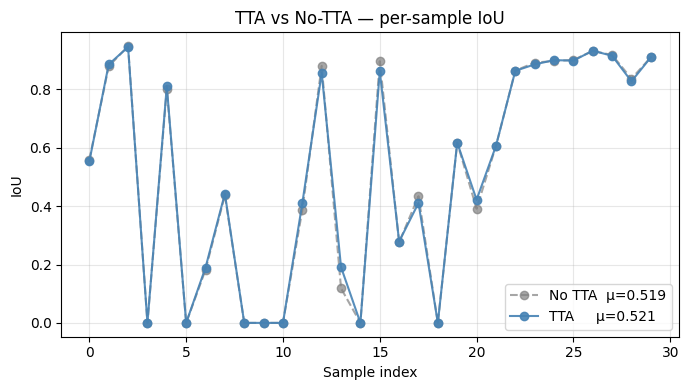

In [18]:

SAMPLE_N = min(30, len(test_images))
sample_paths = test_images[:SAMPLE_N]

tta_ious, no_tta_ious = [], []

for img_p in tqdm(sample_paths, desc='TTA comparison'):
    msk_p = TEST_MASK / img_p.name
    if not msk_p.exists(): continue
    gt = (cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)

    for use_tta, store in [(True, tta_ious), (False, no_tta_ious)]:
        r = run_segmentation(img_p, model, device,
                             threshold=BEST_THRESHOLD, tta=use_tta, min_area=0)
        pred = (r.binary_mask > 127).astype(np.uint8)
        tp = np.logical_and(pred, gt).sum()
        fp = np.logical_and(pred, 1 - gt).sum()
        fn = np.logical_and(1 - pred, gt).sum()
        store.append(tp / (tp + fp + fn + 1e-8))

print(f'No TTA  IoU: {np.mean(no_tta_ious):.4f} ± {np.std(no_tta_ious):.4f}')
print(f'TTA     IoU: {np.mean(tta_ious):.4f} ± {np.std(tta_ious):.4f}')
print(f'Delta       : {np.mean(tta_ious) - np.mean(no_tta_ious):+.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(no_tta_ious, 'o--', color='gray',      alpha=0.7, label=f'No TTA  μ={np.mean(no_tta_ious):.3f}')
ax.plot(tta_ious,    'o-',  color='steelblue', alpha=0.9, label=f'TTA     μ={np.mean(tta_ious):.3f}')
ax.set_xlabel('Sample index'); ax.set_ylabel('IoU')
ax.set_title('TTA vs No-TTA — per-sample IoU'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'tta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export Results

In [19]:
csv_cols = ['filename', 'IoU', 'Dice', 'Sensitivity',
            'n_raw_mc', 'n_clusters', 'max_prob', 'mean_prob', 'inf_ms']
df[csv_cols].to_csv(OUT_DIR / 'test_results.csv', index=False)
print(f'Results saved -> {OUT_DIR}/test_results.csv')

if full_mam_paths:
    save_binary_mask(full_result, OUT_DIR / f'{full_path.stem}_mask.png')
    save_overlay(full_path, full_result, OUT_DIR / f'{full_path.stem}_overlay.png')
    save_report(full_result, full_path, OUT_DIR / f'{full_path.stem}_report.json')

print()
print('=' * 55)
print('  FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Checkpoint        : {CKPT.name}')
print(f'  Threshold         : {BEST_THRESHOLD}')
print(f'  TTA               : False')
print(f'  Cluster dist      : {CLUSTER_DIST}px')
print(f'  Test patches      : {len(df)}')
print(f'  IoU               : {df["IoU"].mean():.4f} +/- {df["IoU"].std():.4f}')
print(f'  Dice              : {df["Dice"].mean():.4f} +/- {df["Dice"].std():.4f}')
print(f'  Sensitivity       : {df["Sensitivity"].mean():.4f} +/- {df["Sensitivity"].std():.4f}')
print(f'  AUC-ROC           : {auc_roc:.4f}')
print(f'  AUC-PR            : {auc_pr:.4f}')
print(f'  Det Recall        : {det_recall:.4f}  (centroid dist<=10px)')
print(f'  Det Precision     : {det_precision:.4f}')
print(f'  Det F1            : {det_f1:.4f}')
print(f'  Avg raw MC/patch  : {df["n_raw_mc"].mean():.1f}')
print(f'  Avg clusters/patch: {df["n_clusters"].mean():.1f}')
print(f'  Avg inf time      : {df["inf_ms"].mean():.1f} ms/patch')
print(f'  Output dir        : {OUT_DIR}')
print('=' * 55)


Results saved -> ..\outputs\segment_inference/test_results.csv
[segment] Mask saved    → ..\outputs\segment_inference\20587148_fd746d25eb40b3dc_MG_R_CC_ANON_mask.png
[segment] Overlay saved → ..\outputs\segment_inference\20587148_fd746d25eb40b3dc_MG_R_CC_ANON_overlay.png
[segment] Report saved  → ..\outputs\segment_inference\20587148_fd746d25eb40b3dc_MG_R_CC_ANON_report.json

  FINAL RESULTS SUMMARY
  Checkpoint        : unet_best.pth
  Threshold         : 0.5
  TTA               : False
  Cluster dist      : 100px
  Test patches      : 184
  IoU               : 0.5521 +/- 0.3045
  Dice              : 0.6507 +/- 0.3161
  Sensitivity       : 0.6848 +/- 0.3310
  AUC-ROC           : 0.9642
  AUC-PR            : 0.8009
  Det Recall        : 0.2089  (centroid dist<=10px)
  Det Precision     : 0.9195
  Det F1            : 0.3404
  Avg raw MC/patch  : 0.5
  Avg clusters/patch: 0.4
  Avg inf time      : 554.8 ms/patch
  Output dir        : ..\outputs\segment_inference
